In [ ]:
url <- "https://www-nds.iaea.org/amdc/ame2020/mass_1.mas20.txt"
download.file(url, "mass_1.mas20.txt")
lines <- readLines("mass_1.mas20.txt")
length(lines)

[1] 3594

In [ ]:
cat(head(lines, 40), sep = "\n")

1    a0dsskgw                                 A T O M I C   M A S S   A D J U S T M E N T
0                                                     DATE  3 Mar 2021 TIME 22:41
0        *********************                               A=   0 TO 295
         * file : mass.mas20 *
         *********************

   This is one file out of a series of 3 files published in:
       "The Ame2020 atomic mass evaluation (I)"   by W.J.Huang, M.Wang, F.G.Kondev, G.Audi and S.Naimi
           Chinese Physics C45, 030002, March 2021.
       "The Ame2020 atomic mass evaluation (II)"  by M.Wang, W.J.Huang, F.G.Kondev, G.Audi and S.Naimi
           Chinese Physics C45, 030003, March 2021.
                       for files : mass.mas20 : atomic masses
                                   rct1.mas20 : react and sep energies,  part 1
                                   rct2.mas20 : react and sep energies,  part 2
   A fourth file  is the "Rounded" version of the atomic mass table (the first file)
            

In [ ]:
lines <- readLines("mass_1.mas20.txt")

# Data rows: N, Z, A must all parse as integers in cols 5-19
is_data <- nchar(lines) > 100 &
           grepl("^\\s*\\d+\\s+\\d+\\s+\\d+\\s*$", substr(lines, 5, 19))

rows <- lines[is_data]
cat("Header lines:", sum(!is_data), "\n")   # expect 36
cat("Data rows:   ", length(rows), "\n")    # expect 3558

# Estimated values: '#' in the mass excess field or its uncertainty
est <- grepl("#", substr(rows, 29, 54), fixed = TRUE)
cat("Estimated (excluded):", sum(est), "\n")
cat("Measured (kept):     ", sum(!est), "\n")

m <- rows[!est]

num <- function(x, a, b) as.numeric(substr(x, a, b))

df <- data.frame(
  N        = num(m,   5,   9),
  Z        = num(m,  10,  14),
  A        = num(m,  15,  19),
  D        = num(m,  29,  42),   # mass excess, keV
  sigma    = num(m,  43,  54),   # its uncertainty, keV
  BA_table = num(m,  55,  67)    # AME's own B/A, for checking
)

DH <- 7288.97106
Dn <- 8071.31806

df$B  <- df$Z * DH + df$N * Dn - df$D
df$BA <- df$B / df$A

Header lines: 36 
Data rows:    3558 
Estimated (excluded): 1008 
Measured (kept):      2550 


In [ ]:
d <- df$BA - df$BA_table
summary(d)
sum(abs(d) > 1, na.rm = TRUE)   # count exceeding your 1 keV tolerance

      Min.    1st Qu.     Median       Mean    3rd Qu.       Max. 
-1.067e-04 -2.854e-05 -3.127e-06 -3.694e-06  2.000e-05  6.476e-05 

[1] 0

In [ ]:
subset(df, Z == 26 & A == 56)$BA   # ~8790.34
subset(df, Z == 28 & A == 62)$BA   # ~8794.53

[1] 8790.356

[1] 8794.556

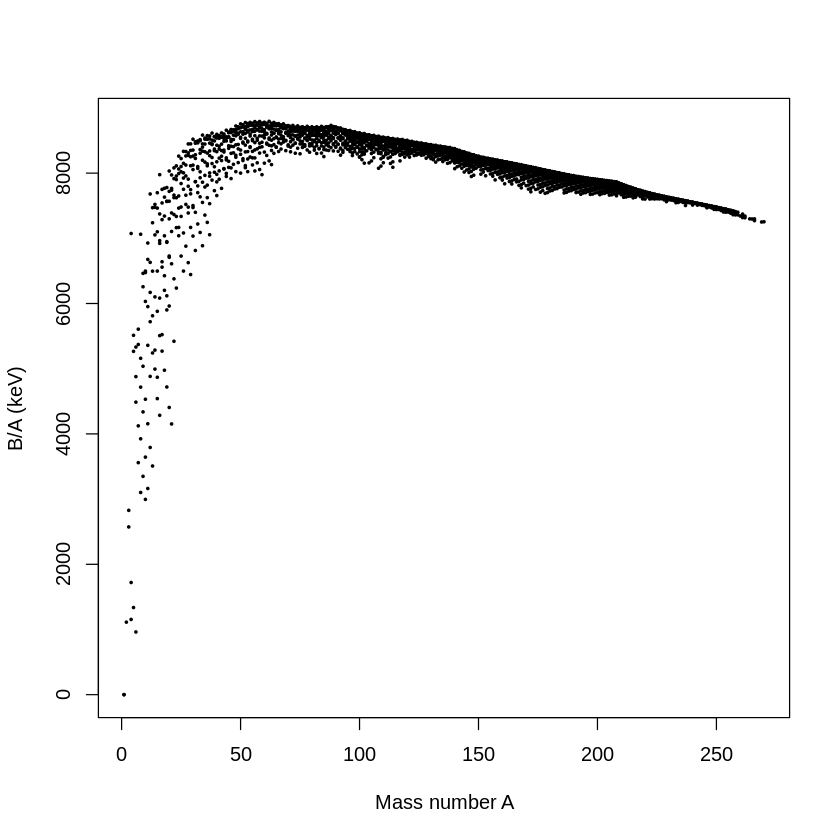

In [ ]:
plot(df$A, df$BA, pch = 20, cex = 0.4,
     xlab = "Mass number A", ylab = "B/A (keV)")

In [ ]:
key <- paste(df$Z, df$A)
df$Sn  <- df$B - df$B[match(paste(df$Z, df$A - 1), key)]
df$S2n <- df$B - df$B[match(paste(df$Z, df$A - 2), key)]

Maximum: 28 62 8794.556 


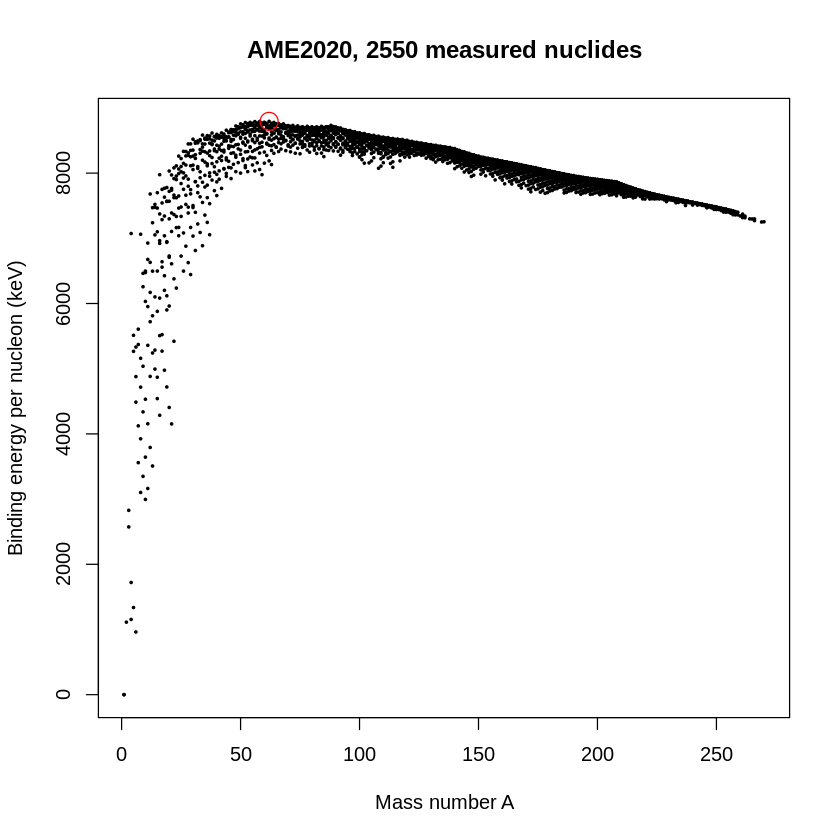

In [ ]:
plot(df$A, df$BA, pch = 20, cex = 0.4,
     xlab = "Mass number A", ylab = "Binding energy per nucleon (keV)",
     main = "AME2020, 2550 measured nuclides")

peak <- df[which.max(df$BA), ]
points(peak$A, peak$BA, col = "red", pch = 1, cex = 2)
cat("Maximum:", peak$Z, peak$A, peak$BA, "\n")

In [ ]:
key <- paste(df$Z, df$A)
df$Sn  <- df$B - df$B[match(paste(df$Z, df$A - 1), key)]
df$S2n <- df$B - df$B[match(paste(df$Z, df$A - 2), key)]

cat("Sn computable: ", sum(!is.na(df$Sn)),  "of", nrow(df), "\n")
cat("S2n computable:", sum(!is.na(df$S2n)), "of", nrow(df), "\n")
cat("Negative S2n:  ", sum(df$S2n < 0, na.rm = TRUE), "\n")

Sn computable:  2393 of 2550 
S2n computable: 2301 of 2550 
Negative S2n:   9 


In [ ]:
url1 <- "https://www-nds.iaea.org/amdc/ame2020/rct1.mas20.txt"
download.file(url1, "rct1.mas20.txt")
r1 <- readLines("rct1.mas20.txt")
length(r1)

cat(head(r1, 40), sep = "\n")

[1] 3593

1    a0dsskgw                                 A T O M I C   M A S S   A D J U S T M E N T
0                                                     DATE  3 Mar 2021 TIME 22:41
0        *********************                               A=   0 TO 295
         * file : rct1.mas20 *
         *********************

   This is one file out of a series of 3 files published in:
       "The Ame2020 atomic mass evaluation (I)"   by W.J.Huang, M.Wang, F.G.Kondev, G.Audi and S.Naimi
           Chinese Physics C45, 030002, March 2021.
       "The Ame2020 atomic mass evaluation (II)"  by M.Wang, W.J.Huang, F.G.Kondev, G.Audi and S.Naimi
           Chinese Physics C45, 030003, March 2021.
                       for files : mass.mas20 : atomic masses
                                   rct1.mas20 : react and sep energies,  part 1
                                   rct2.mas20 : react and sep energies,  part 2
   A fourth file  is the "Rounded" version of the atomic mass table (the first file)
            

In [1]:
plot(df$A, df$BA, pch = 20, cex = 0.4,
     xlab = "Mass number A",
     ylab = "Binding energy per nucleon (keV)",
     main = "AME2020, 2550 measured nuclides")

peak <- df[which.max(df$BA), ]
points(peak$A, peak$BA, col = "red", pch = 1, cex = 2)
cat("Maximum: Z =", peak$Z, " A =", peak$A, " B/A =", peak$BA, "\n")

head(df[order(-df$BA), c("Z", "N", "A", "BA")], 5)

ERROR: Error in df$A: object of type 'closure' is not subsettable
